## Setup

In [ ]:
using_colab = True

In [ ]:
!git clone https://github.com/facebookresearch/sam-3d-body
%cd sam-3d-body

Cloning into 'sam-3d-body'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 184 (delta 38), reused 14 (delta 14), pack-reused 70 (from 1)
Receiving objects: 100% (184/184), 22.39 MiB | 44.18 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/sam-3d-body


In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!pip install huggingface_hub

from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="facebook/sam-3d-body-dinov3",
    local_dir="./checkpoints/sam-3d-body-dinov3"
)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'/content/sam-3d-body/checkpoints/sam-3d-body-dinov3'

In [ ]:
!pip install braceexpand
!pip install roma
!pip install pytorch-lightning
!pip install yacs
!pip install pyrender

# 1. Install prerequisites for building
!pip install 'git+https://github.com/facebookresearch/detectron2.git'
!pip install git+https://github.com/microsoft/MoGe.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 33.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 52.3 MB/s eta 0:00:00
  Created wheel for PyOpenGL: filename=PyOpenGL-3.1.0-py3-none-any.whl size=1745193 sha256=a36ea2039080d21e66a9c66d0d550e551844b15fece252a750e58b352f25236d
  Stored in directory: /root/.cache/pip/wheels/5c/d0/77/e69597cdbcb72ea27345036f549a737909bcf17c39789472ce
Successfully built PyOpenGL
  Attempting uninstall: PyOpenGL
    Found existing installation: PyOpenGL 3.1.10
    Uninstalling PyOpenGL-3.1.10:

In [ ]:
!nvidia-smi

Fri May 15 22:15:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# font size for axes titles
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id):
    # we will just propagate from frame 0 to the end of the video
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]

    return outputs_per_frame


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

In [ ]:
import sys
import os
import importlib

# 1. Definimos la ruta raíz del repositorio
repo_root = '/content/sam-3d-body'

# 2. Forzamos a Python a mirar primero en tu carpeta local
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# 3. CRUCIAL: Eliminamos la referencia a la librería del sistema de la memoria
if 'notebook' in sys.modules:
    del sys.modules['notebook']
if 'notebook.utils' in sys.modules:
    del sys.modules['notebook.utils']

# 4. Intentamos la importación usando el espacio de nombres del paquete
try:
    # Intentamos la ruta que coincide con tu estructura de carpetas
    from sam_3d_body.notebook.utils import setup_sam_3d_body
    from sam_3d_body.tools.vis_utils import visualize_sample_together
    print("✅ Importación exitosa desde 'sam_3d_body'!")
except ImportError:
    try:
        # Intento alternativo si los archivos están en la raíz de la carpeta notebook/
        from notebook.utils import setup_sam_3d_body
        from tools.vis_utils import visualize_sample_together
        print("✅ Importación exitosa desde la raíz del repo!")
    except ImportError as e:
        print(f"❌ No se pudo importar: {e}")
        print("\nBuscando ubicación real del archivo...")
        !find /content/sam-3d-body -name "utils.py"

# 5. Inicializar el modelo
if 'setup_sam_3d_body' in locals():
    estimator = setup_sam_3d_body(
        hf_repo_id="facebook/sam-3d-body-dinov3"
    )

/content/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


✅ Importación exitosa desde la raíz del repo!
Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...
Downloading: "https://github.com/facebookresearch/dinov3/zipball/main" to /root/.cache/torch/hub/main.zip



missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parameter_transform, head_pose.mhr.character_torch.parameter_transform.pose_parameters, head_pose.mhr.character_torch.parameter_transform.rigid_parameters, head_pose.mhr.char

Loading human detector from vitdet...
########### Using human detector: ViTDet...


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
model_final_f05665.pkl: 2.77GB [00:55, 50.2MB/s]                            


Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...


model.pt:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓


## Load segmented frames of a video

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from importlib.machinery import SourceFileLoader

# 1. CONFIGURACIÓN DE RUTAS
ruta_base = f"/content/drive/MyDrive/TFG/Press/Img"

ruta_entrada = os.path.join(ruta_base, "Segmented_Frames/bench_press_10")
ruta_salida = os.path.join(ruta_base, "Estimated_Pose_Frames/bench_press_10")
ruta_data_keypoints = os.path.join(ruta_base, "Keypoints/bench_press_10")

os.makedirs(ruta_salida, exist_ok=True)
os.makedirs(ruta_data_keypoints, exist_ok=True)

# 2. CARGAR UTILIDADES (vis_utils)
repo_3d = '/content/sam-3d-body'
vis_utils_path = os.path.join(repo_3d, 'tools/vis_utils.py')

if os.path.exists(vis_utils_path):
    vis_utils = SourceFileLoader("vis_utils", vis_utils_path).load_module()
    print("✅ Módulo 'vis_utils' cargado correctamente.")
else:
    raise FileNotFoundError("No se encontró vis_utils.py en el repositorio.")

# 3. OBTENER LISTA DE FRAMES (Ordenados para el vídeo)
frame_files = sorted([f for f in os.listdir(ruta_entrada) if f.endswith('.png')])
n_frames = len(frame_files)
print(f"🔎 Se han encontrado {len(frame_files)} frames para procesar.")

# 4. BUCLE DE PROCESAMIENTO
# Usamos tqdm para ver la barra de progreso
all_keypoints = np.full((n_frames, 127, 3), np.nan)

for i, filename in enumerate(tqdm(frame_files, desc="Procesando Biomecánica 3D")):

    # A. Cargar imagen
    img_path = os.path.join(ruta_entrada, filename)
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue

    # B. Preparar imagen para el modelo
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # C. Inferencia (Estimación de Pose 3D)
    with torch.no_grad(): # Ahorramos memoria GPU
        outputs = estimator.process_one_image(img_rgb)

    # D. Verificación de detección
    if outputs is not None and len(outputs) > 0:
        res = outputs[0] if isinstance(outputs, list) else outputs

        if 'pred_joint_coords' in res:
            joints = res['pred_joint_coords'] # (127, 3)
            if hasattr(joints, "cpu"): joints = joints.cpu().numpy()

            # Guardamos los 127 puntos
            all_keypoints[i] = joints

        # E. Renderizado visual
        try:
            outputs_list = outputs if isinstance(outputs, list) else [outputs]
            rendered = vis_utils.visualize_sample_together(img_rgb, outputs_list, estimator.faces)
            cv2.imwrite(os.path.join(ruta_salida, filename), cv2.cvtColor(rendered, cv2.COLOR_RGB2BGR))
        except:
            pass
    else:
        # Frame negro si no hay detección
        h, w = img_rgb.shape[:2]
        cv2.imwrite(os.path.join(ruta_salida, filename), np.zeros((h*2, w*2, 3), np.uint8))

# F. Guardado
archivo_npy = os.path.join(ruta_data_keypoints, "keypoints_3d_bench_press_10.npy")
np.save(archivo_npy, all_keypoints)

print(f"\n✅ PROCESO COMPLETADO")
print(f"📂 Todos los frames con pose estimada están en: {ruta_salida}")

✅ Módulo 'vis_utils' cargado correctamente.
🔎 Se han encontrado 53 frames para procesar.


Procesando Biomecánica 3D:   0%|          | 0/53 [00:00<?, ?it/s]

####### Please make sure the input image is in RGB format
Running object detector...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0515 22:19:06.580000 624 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Found boxes: [[ 360.50763  280.91187 1239.4739  1069.4778 ]]
Running FOV estimator ...


...

####### Please make sure the input image is in RGB format
Running object detector...
Found boxes: [[ 359.40955  265.52695 1238.3253  1069.7784 ]]
Running FOV estimator ...


Procesando Biomecánica 3D:  98%|█████████▊| 52/53 [09:58<00:11, 11.35s/it]

####### Please make sure the input image is in RGB format
Running object detector...
Found boxes: [[ 359.7223  265.5933 1238.2711 1069.9569]]
Running FOV estimator ...


Procesando Biomecánica 3D: 100%|██████████| 53/53 [10:09<00:00, 11.51s/it]



✅ PROCESO COMPLETADO
📂 Todos los frames con pose estimada están en: /content/drive/MyDrive/TFG/Press/Img/Estimated_Pose_Frames/bench_press_10


In [ ]:
import cv2
import os
import time
import shutil
from tqdm import tqdm

# 1. Rutas de ENTRADA (Desde tu Drive)
nombre_acceso_directo = "TFG"
ruta_base_drive = f"/content/drive/MyDrive/{nombre_acceso_directo}/Press"
ruta_frames_pose = os.path.join(ruta_base_drive, "Img/Estimated_Pose_Frames/bench_press_10")

# 2. Rutas de PROCESO (En el disco local de Colab, mucho más rápido y sin errores)
video_temp_local = "/content/temp_raw.mp4"
video_final_local = "/content/video_final_compatible.mp4"

# 3. Ruta de SALIDA (A tu Drive)
video_salida_drive = os.path.join(ruta_base_drive, "Vid/bench_press_10_estimated_pose.mp4")
os.makedirs(os.path.dirname(video_salida_drive), exist_ok=True)

# --- PASO 1: UNIR FRAMES ---
frame_files = sorted([f for f in os.listdir(ruta_frames_pose) if f.endswith('.png')])
primer_frame = cv2.imread(os.path.join(ruta_frames_pose, frame_files[0]))
alto, ancho, _ = primer_frame.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_temp_local, fourcc, 30, (ancho, alto))

print(f"🎬 Paso 1/3: Uniendo {len(frame_files)} frames en disco local...")
for filename in tqdm(frame_files, desc="Generando MP4"):
    frame = cv2.imread(os.path.join(ruta_frames_pose, filename))
    if frame is not None:
        out.write(frame)
out.release()

# --- PASO 2: CONVERTIR CON FFMEPG (En disco local) ---
print(f"🔄 Paso 2/3: Convirtiendo a H.264 compatible...")
# Aquí FFmpeg no fallará porque lee y escribe en el disco duro de la máquina virtual
os.system(f'ffmpeg -i "{video_temp_local}" -vcodec libx264 -crf 23 -pix_fmt yuv420p -y "{video_final_local}"')

# --- PASO 3: MOVER AL DRIVE ---
print(f"📂 Paso 3/3: Trasladando vídeo final al Google Drive...")
if os.path.exists(video_final_local) and os.path.getsize(video_final_local) > 0:
    shutil.copy(video_final_local, video_salida_drive)
    print(f"\n✅ ¡PROCESO COMPLETADO!")
    print(f"📍 Tu vídeo está aquí: {video_salida_drive}")

    # Limpieza del disco local de Colab
    os.remove(video_temp_local)
    os.remove(video_final_local)
else:
    print("\n❌ Error crítico: El vídeo no se pudo convertir en el disco local.")

🎬 Paso 1/3: Uniendo 53 frames en disco local...


Generando MP4: 100%|██████████| 53/53 [00:07<00:00,  6.89it/s]


🔄 Paso 2/3: Convirtiendo a H.264 compatible...
📂 Paso 3/3: Trasladando vídeo final al Google Drive...

✅ ¡PROCESO COMPLETADO!
📍 Tu vídeo está aquí: /content/drive/MyDrive/TFG/Press/Vid/bench_press_10_estimated_pose.mp4


In [ ]:
import numpy as np

def calcular_distancia_3d(p1, p2):
    """Calcula la distancia euclídea entre dos puntos en el espacio 3D."""
    return np.linalg.norm(p1 - p2)

def calcular_angulo_3d(p1, p2, p3):
    """Calcula el ángulo en el punto p2 formado por p1-p2 y p3-p2"""
    v1 = p1 - p2
    v2 = p3 - p2

    # Producto escalar y normas
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    if norm_v1 < 1e-6 or norm_v2 < 1e-6:
        return np.nan  # evitar basura

    # Coseno del ángulo con clip para evitar errores numéricos
    cos_theta = dot_product / (norm_v1 * norm_v2)
    angle = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    return np.degrees(angle)

def calcular_grip_ratio(frame_data):
    # 1. Distancia entre muñecas (Ancho del agarre)
    # Usamos 3D para captar la distancia real entre manos aunque estén en diagonal
    dist_agarre = np.linalg.norm(frame_data[78] - frame_data[42])

    # 2. Referencia: Longitud de un brazo (Hombro -> Codo -> Muñeca)
    # Esta medida es constante aunque el sujeto gire
    arm_l = np.linalg.norm(frame_data[75] - frame_data[76]) + \
            np.linalg.norm(frame_data[76] - frame_data[78])

    # 3. Ratio basado en brazo
    ratio = dist_agarre / arm_l
    return ratio

def calcular_inclinacion_torso(p_shoulder, p_hip):
    # Vector que va desde la cadera hacia el hombro (hacia arriba)
    # Importante: Usamos X e Y (0 y 1). Asegúrate de qué eje es la altura en tu .npy
    # Si el eje 1 (Y) es la altura:
    v_torso = np.array([p_shoulder[0] - p_hip[0], p_shoulder[1] - p_hip[1]])

    # La vertical pura en este plano
    vertical = np.array([0, -1]) # Probamos -1 si Y crece hacia abajo

    v_torso /= (np.linalg.norm(v_torso) + 1e-6)
    dot = np.dot(v_torso, vertical)
    angulo = np.degrees(np.arccos(np.clip(dot, -1, 1)))

    # Si el ángulo sale > 90, es que el vector está invertido
    return angulo if angulo < 90 else 180 - angulo

def calcular_ratio_apertura(hip_izq, knee_izq, hip_der, knee_der):
    """
    Mide la apertura de las rodillas comparada con las caderas.
    Si las rodillas están más abiertas que las caderas, el ratio es > 1.
    """
    dist_caderas = calcular_distancia_3d(hip_izq, hip_der)
    dist_rodillas = calcular_distancia_3d(knee_izq, knee_der)

    if dist_caderas == 0: return 1.0
    return dist_rodillas / dist_caderas

def calibrar_antropometria(data):
    """
    Calcula el tipo de cuerpo usando las distancias máximas encontradas
    en todo el vídeo para evitar errores de perspectiva en el lockout.
    """
    # Calculamos las longitudes para todos los frames
    # Usamos np.linalg.norm en los 3 ejes (X, Y, Z) para mitigar la perspectiva

    # Segmento Torso: Hombro a Cadera
    torsos = np.linalg.norm(data[:, 75] - data[:, 2], axis=1)
    # Segmento Pierna: Cadera a Tobillo
    piernas = np.linalg.norm(data[:, 2] - data[:, 4], axis=1)

    # Filtramos posibles ceros o errores de detección (NaN)
    longitud_torso = np.nanpercentile(torsos, 90) # Usamos el percentil 90 para evitar picos de ruido
    longitud_pierna = np.nanpercentile(piernas, 90)

    ratio = longitud_torso / longitud_pierna

    if ratio > 0.68: # Umbrales ligeramente ajustados
        tipo = "Torso Largo"
    elif ratio < 0.58:
        tipo = "Piernas Largas"
    else:
        tipo = "Estandar"

    return tipo, ratio

def calcular_desplazamiento_normalizado(p_actual, p_referencia, longitud_brazo):
    """
    Calcula cuánto se ha movido un punto respecto a su inicio,
    normalizado por el tamaño del brazo del atleta.
    """
    distancia_abs = np.linalg.norm(p_actual - p_referencia)
    return distancia_abs / longitud_brazo

In [ ]:
def analizar_tecnica_triceps_pushdown(max_elbow_angle, max_shoulder_disp, max_torso_angle):
    """
    Evalúa la técnica de extensión de tríceps en polea alta.
    """
    # REGLA 1: EXTENSIÓN COMPLETA (Criterio Principal)
    if max_elbow_angle > 150:
        es_correcta = True
        msg_principal = "✅ TÉCNICA CORRECTA: Extensión completa alcanzada."
    else:
        es_correcta = False
        msg_principal = "❌ TÉCNICA INCORRECTA: Rango incompleto."

    # OBSERVACIONES TÉCNICAS
    # 1. Estabilidad del Hombro
    msg_hombro = "✅ Hombros estables durante el movimiento."
    if max_shoulder_disp > 0.25: # Umbral de tolerancia ligeramente flexible
        msg_hombro = "⚠️ AVISO: Movimiento excesivo del hombro."

    # 2. Inclinación Torso
    msg_torso = "✅ Torso estable."
    if max_torso_angle > 30:
        msg_torso = "⚠️ AVISO: Inclinación de torso detectada."

    return es_correcta, msg_principal, msg_hombro, msg_torso

Referencia fijada en Frame 0 (Inicio de la bajada)
     INFORME BIOMECÁNICO: TRICEPS PUSH   
Análisis realizado en el Frame (Pico): 30
-> Ángulo máx. extensión: 154.94°
-> Desplazamiento hombro: 0.1278
-> Inclinación máx torso: 20.96°
-----------------------------------------
VERDICTO PRINCIPAL:
✅ TÉCNICA CORRECTA: Extensión completa alcanzada.

OBSERVACIONES TÉCNICAS:
✅ Hombros estables durante el movimiento.
✅ Torso estable.


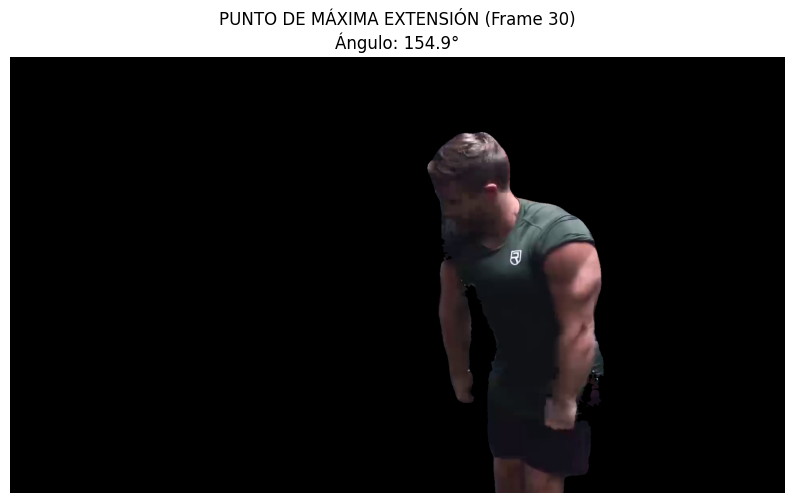

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# --- 1. CARGA DE DATOS ---
# Ajusta la ruta a tu archivo .npy de Tríceps
data = np.load('/content/drive/MyDrive/TFG/Pushdown/Img/Keypoints/tricep_pushdown_3/keypoints_3d_tricep_pushdown_3.npy')

# --- 2. CALIBRACIÓN AL INICIO DE LA CONCÉNTRICA ---
# Primero calculamos los ángulos de codo de todo el video para encontrar el "inicio"
angulos_codo_todos = [calcular_angulo_3d(data[f, 75], data[f, 76], data[f, 78]) for f in range(len(data))]

# El inicio de la concéntrica es cuando el codo está lo más flexionado posible (ángulo mínimo)
idx_inicio = np.nanargmin(angulos_codo_todos)
shoulder_ref = data[idx_inicio, 75]

# Longitud del brazo (usamos el máximo para evitar errores de perspectiva)
distancias_brazo = np.linalg.norm(data[:, 75] - data[:, 76], axis=1)
long_brazo = np.nanmax(distancias_brazo)

print(f"Referencia fijada en Frame {idx_inicio} (Inicio de la bajada)")

metrics_per_frame = []

# --- 3. BUCLE DE PROCESAMIENTO ---
for frame in range(len(data)):
    shoulder = data[frame, 75]
    elbow    = data[frame, 76]
    wrist    = data[frame, 78]
    hip      = data[frame, 2]

    # Métrica 1: Ángulo de codo
    # En extensión completa debería acercarse a 180°
    ang_codo = calcular_angulo_3d(shoulder, elbow, wrist)

    # Métrica 2: Desplazamiento del hombro (Normalizado)
    disp_hombro = calcular_desplazamiento_normalizado(shoulder, shoulder_ref, long_brazo)

    # Métrica 3: Inclinación del torso
    ang_torso = calcular_inclinacion_torso(shoulder, hip)

    metrics_per_frame.append([ang_codo, disp_hombro, ang_torso])

metrics_array = np.array(metrics_per_frame)

# --- 4. EXTRACCIÓN DE RESULTADOS (Punto de máxima extensión) ---
# Buscamos el frame donde el ángulo del codo es mayor (brazo más estirado)
idx_peak = np.nanargmax(metrics_array[:, 0])

max_elbow_val  = metrics_array[idx_peak, 0]
max_disp_val   = metrics_array[idx_peak, 1]
max_torso_val  = np.nanmax(metrics_array[:, 2]) # El máximo balanceo detectado

# --- 5. LLAMADA A LA FUNCIÓN DE REGLAS ---
es_ok, txt_principal, txt_hombro, txt_torso = analizar_tecnica_triceps_pushdown(
    max_elbow_val, max_disp_val, max_torso_val
)

# --- 6. INFORME FINAL ---
print("=========================================")
print("     INFORME BIOMECÁNICO: TRICEPS PUSH   ")
print("=========================================")
print(f"Análisis realizado en el Frame (Pico): {idx_peak}")
print(f"-> Ángulo máx. extensión: {max_elbow_val:.2f}°")
print(f"-> Desplazamiento hombro: {max_disp_val:.4f}")
print(f"-> Inclinación máx torso: {max_torso_val:.2f}°")
print("-----------------------------------------")
print(f"VERDICTO PRINCIPAL:")
print(txt_principal)
print("\nOBSERVACIONES TÉCNICAS:")
print(txt_hombro)
print(txt_torso)
print("=========================================")

# --- 7. VALIDACIÓN VISUAL ---
folder_path = '/content/drive/MyDrive/TFG/Pushdown/Img/Segmented_Frames/tricep_pushdown_3/'
filename = f"frame_{idx_peak + 1:04d}.png"
img_path = os.path.join(folder_path, filename)

try:
    plt.figure(figsize=(10, 7))
    plt.imshow(mpimg.imread(img_path))
    plt.title(f"PUNTO DE MÁXIMA EXTENSIÓN (Frame {idx_peak})\nÁngulo: {max_elbow_val:.1f}°")
    plt.axis('off')
    plt.show()
except FileNotFoundError:
    print(f"⚠️ Imagen no encontrada en {img_path}")

In [ ]:
import cv2
import numpy as np
import os

# 1. Configuración de archivos y carga de datos
# Cambia estas rutas a las de tu ejercicio actual
video_input = '/content/drive/MyDrive/TFG/Pushdown/Vid/tricep_pushdown_3.mp4'
video_output = '/content/drive/MyDrive/TFG/Pushdown/Vid/tricep_pushdown_3_analyzed.mp4'

cap = cv2.VideoCapture(video_input)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_output, fourcc, fps, (w, h))

# --- UMBRALES SEGÚN TU FUNCIÓN analizar_tecnica_triceps_pushdown ---
UMBRAL_ELBOW_EXT = 150   # Mínimo para considerar extensión completa
UMBRAL_SH_DISP = 0.25    # Máximo desplazamiento permitido
UMBRAL_TORSO_INC = 30    # Máxima inclinación permitida

print(f"Iniciando renderizado de vídeo: {os.path.basename(video_input)}")

for frame_idx in range(len(metrics_array)):
    ret, frame = cap.read()
    if not ret: break

    # Extraer métricas del array: [ang_codo, disp_hombro, ang_torso]
    ang_codo, disp_hombro, ang_torso = metrics_array[frame_idx]

    # --- A. LÓGICA DE ESTADO (Métrica Principal: Extensión de Codo) ---
    if ang_codo >= UMBRAL_ELBOW_EXT:
        status_txt = "EXTENSION OK"
        color_status = (0, 255, 0)  # Verde
    else:
        status_txt = "EXTENSION INCOMPLETA"
        color_status = (0, 0, 255) # Rojo

    # Dibujar cuadro de estado superior
    cv2.rectangle(frame, (30, 30), (520, 95), (0, 0, 0), -1)
    cv2.putText(frame, status_txt, (50, 75), cv2.FONT_HERSHEY_SIMPLEX, 1, color_status, 2)

    # --- B. TELEMETRÍA Y ALERTAS TÉCNICAS ---
    def draw_metric(img, label, val, unit, y_pos, alert_condition):
        color = (255, 255, 255)
        txt = f"{label}: {val:.2f}{unit}"
        # Sombra para legibilidad
        cv2.putText(img, txt, (50, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 3)
        cv2.putText(img, txt, (50, y_pos), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # Mostramos las métricas con alertas
    draw_metric(frame, "Ang. Codo", ang_codo, " deg", 140, ang_codo < UMBRAL_ELBOW_EXT)
    draw_metric(frame, "Despl. Hombro", disp_hombro, "", 175, disp_hombro > UMBRAL_SH_DISP)
    draw_metric(frame, "Inc. Torso", ang_torso, " deg", 210, ang_torso > UMBRAL_TORSO_INC)

    # --- C. MENSAJES DE AVISO (Basados en tus reglas) ---
    y_msg = 300

    # Alerta de Hombro (Trampa)
    if disp_hombro > UMBRAL_SH_DISP:
        cv2.putText(frame, "(!) ALERTA: MOVIMIENTO DE HOMBRO", (50, y_msg), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)
        y_msg += 40

    # Alerta de Torso (Balanceo)
    if ang_torso > UMBRAL_TORSO_INC:
        cv2.putText(frame, "(!) ALERTA: BALANCEO DE TORSO", (50, y_msg), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)
        y_msg += 40

    out.write(frame)

cap.release()
out.release()
print(f"✅ Proceso completado. Vídeo guardado en: {video_output}")

Iniciando renderizado de vídeo: tricep_pushdown_3.mp4
✅ Proceso completado. Vídeo guardado en: /content/drive/MyDrive/TFG/Pushdown/Vid/tricep_pushdown_3_analyzed.mp4
